## Data Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

### Load Data
`load_data` figures out the file format and, for delimited text, the separator, on its own — no assumptions are hardcoded here.

In [2]:
def load_data(path):
    """
    Load a tabular data file into a pandas DataFrame without assuming its
    format or, for delimited text, its separator. Tries readers roughly in
    order of what the extension suggests, then falls through the rest —
    including generic delimiter sniffing — until one works.
    """
    import pandas as pd
    from pathlib import Path

    ext = Path(path).suffix.lower()

    def read_delimited(p):
        # sep=None + engine="python" makes pandas sniff the actual delimiter
        # (comma, semicolon, tab, pipe, whitespace, ...) from the file itself.
        return pd.read_csv(p, sep=None, engine="python")

    candidates = {
        "excel": lambda p: pd.read_excel(p),
        "json": lambda p: pd.read_json(p),
        "parquet": lambda p: pd.read_parquet(p),
        "feather": lambda p: pd.read_feather(p),
        "delimited": read_delimited,
    }

    ext_hint = {
        ".xlsx": "excel", ".xls": "excel", ".xlsm": "excel",
        ".json": "json",
        ".parquet": "parquet",
        ".feather": "feather",
    }.get(ext, "delimited")

    order = [ext_hint] + [k for k in candidates if k != ext_hint]

    errors = {}
    for key in order:
        try:
            df = candidates[key](path)
            if key != ext_hint:
                print(f"Note: '{ext}' didn't load as expected; loaded successfully as {key} instead.")
            return df
        except Exception as e:
            errors[key] = e

    raise ValueError(
        f"Could not load {path!r} with any known reader. Tried: "
        + ", ".join(f"{k} ({e.__class__.__name__})" for k, e in errors.items())
    )


In [3]:
df = load_data('data/bank-full.csv')
df.shape

(45211, 17)

### Initial Inspection

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [5]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### Descriptive Statistics — Numerical Features

In [6]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### Descriptive Statistics — Categorical Features

In [7]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
if len(cat_cols) > 0:
    display(df[cat_cols].describe())
else:
    print('No categorical columns detected.')

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


### Missing Values

In [8]:
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100
missing_summary = pd.DataFrame({'missing_count': missing_count, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing_summary

,missing_count,missing_pct


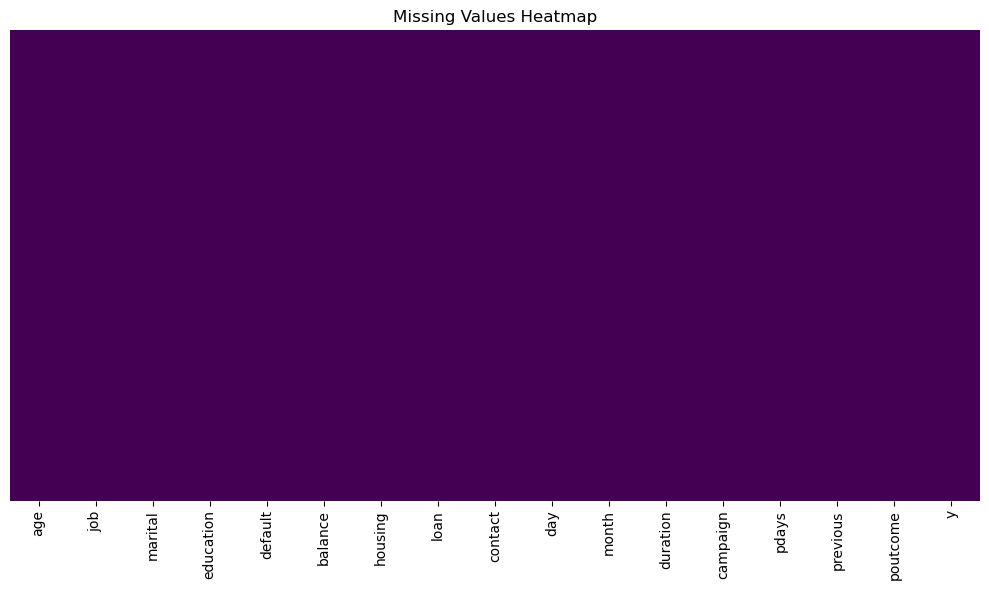

In [9]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

### Duplicate Rows

In [10]:
dup_count = df.duplicated().sum()
print(f'Number of duplicate rows: {dup_count}')
if dup_count > 0:
    display(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()[0]))

Number of duplicate rows: 0
